In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table   
from astropy.coordinates import SkyCoord     
from astropy import units as u                   
from astropy.cosmology import Planck18 as cosmo
from astropy.table import unique
from astropy.visualization import make_lupton_rgb

In [2]:
#read in the catalog
path_to_catalog = '/fs/ess/PCON0003/desi-visualizations/catalogs/zall-tilecumulative-fuji.fits'  
catalog = Table.read(path_to_catalog)

print('Total number of objects:', len(catalog))

Total number of objects: 3611000


In [3]:
# Filter out entries with ZWARN != 0
if 'ZWARN' in catalog.colnames:
    catalog = catalog[catalog['ZWARN'] == 0]

#Filter out high ZERR values
if 'ZERR' in catalog.colnames:
    catalog = catalog[catalog['ZERR'] < 0.001]


#Filter out duplicates
catalog = unique(catalog, keys=['TARGET_RA', 'TARGET_DEC'])
print('Objects kept:', len(catalog))

Objects kept: 1653034


In [4]:
# trim catalog
RA_max = 360   # RA ranges from 0-360
DEC_max = 90   # DEC ranges from -90 to 90 
catalog = catalog[(catalog['TARGET_RA'] < RA_max) & (catalog['TARGET_DEC'] < DEC_max)]

# limit redshift
z_min = 0.01 # below this, they're mostly stars or errors.
z_max = 3    # DESI goes higher than this, but it is sparse and harder to visualize.
catalog = catalog[(catalog['Z'] > z_min) & (catalog['Z'] < z_max)]

# remove galaxies with unrealisting imaging fluxes
flux_g_max = 50  # these are quite faint. You calso can't have negative flux!
flux_g_min = 0
flux_r_max = 50  
flux_r_min = 0
flux_z_max = 50  
flux_z_min = 0
flux_W1_max = 50  
flux_W1_min = 0
flux_W2_max = 50  
flux_W2_min = 0
catalog = catalog[(catalog['FLUX_G'] < flux_g_max) & (catalog['FLUX_G'] > flux_g_min) & (catalog['FLUX_R'] < flux_r_max) & (catalog['FLUX_R'] > flux_r_min) & (catalog['FLUX_Z'] < flux_z_max) & (catalog['FLUX_Z'] > flux_z_min) & (catalog['FLUX_W1'] < flux_W1_max) & (catalog['FLUX_W1'] > flux_W1_min) & (catalog['FLUX_W2'] < flux_W2_max) & (catalog['FLUX_W2'] > flux_W2_min)]

In [5]:
comoving_distance = cosmo.comoving_distance(catalog['Z'])  # calculate the comoving distance to each object based on its redshift and the cosmology (to know: what is comoving distance?)
coords = SkyCoord(ra=catalog['TARGET_RA']*u.degree, dec=catalog['TARGET_DEC']*u.degree, distance=comoving_distance)  # astropy converts this into a 3D coordinate system

In [6]:
#define 3d coords
x = coords.cartesian.x  # these are still astropy objects, i.e. they have assigned units (Mpc)
y = coords.cartesian.y
z = coords.cartesian.z

In [7]:
#define redshift and fluxes
redshift = catalog['Z'] 
flux_g = catalog['FLUX_G']
flux_r = catalog['FLUX_R']
flux_z = catalog['FLUX_Z']
flux_w1 = catalog['FLUX_W1']
flux_w2 = catalog['FLUX_W2']
#xtra
object_type = catalog['SPECTYPE']
zerr = catalog['ZERR']
zwarn = catalog['ZWARN']

In [8]:
#define apparent magnitudes
app_mag_G = -2.5*np.log10(catalog['FLUX_G'])+22.5 
app_mag_R = -2.5*np.log10(catalog['FLUX_R'])+22.5 
app_mag_Z = -2.5*np.log10(catalog['FLUX_Z'])+22.5 
app_mag_W1 = -2.5*np.log10(catalog['FLUX_W1'])+22.5
app_mag_W2 = -2.5*np.log10(catalog['FLUX_W2'])+22.5


In [9]:
#define absolute magnitudes
def apparent_to_absolute_magnitude(m, z):
    d_L = cosmo.luminosity_distance(z)  
    M = m - 5 * np.log10(d_L.to(u.pc).value) + 5  
    return M
abs_mag_g = apparent_to_absolute_magnitude(app_mag_G, redshift)
abs_mag_r = apparent_to_absolute_magnitude(app_mag_R, redshift)
abs_mag_z = apparent_to_absolute_magnitude(app_mag_Z, redshift)
abs_mag_w1 = apparent_to_absolute_magnitude(app_mag_W1, redshift)
abs_mag_w2 = apparent_to_absolute_magnitude(app_mag_W2, redshift)


Reddening Trend Found!
Equation: Color = (0.9108 * Z) + 0.6706


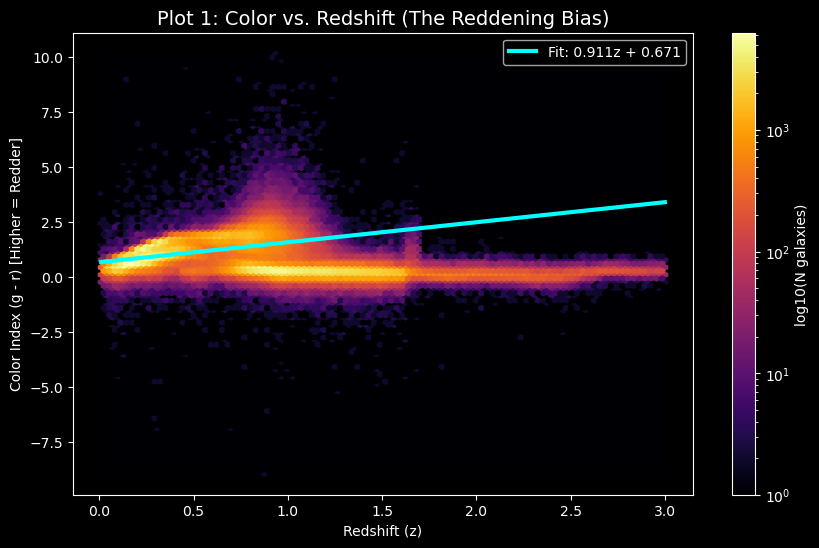

In [12]:
# 1. Calculate the uncorrected color index (g - r)
color_g_r = abs_mag_g - abs_mag_r

z_vals = catalog['Z']
color_vals = color_g_r

# --- THE FIX ---
# Create a mask to isolate the normal galaxies for our math (ignoring high-z quasars)
math_mask = z_vals < 0.8
z_math = z_vals[math_mask]
color_math = color_vals[math_mask]

# 2. Fit the line using ONLY the masked galaxy data
slope, intercept = np.polyfit(z_math, color_math, 1)
# ---------------

print(f"Reddening Trend Found!")
print(f"Equation: Color = ({slope:.4f} * Z) + {intercept:.4f}")

# 3. Create Plot 1
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Use hexbin for massive datasets (creates a density heatmap)
plt.hexbin(z_vals, color_vals, gridsize=100, cmap='inferno', bins='log')
cb = plt.colorbar()
cb.set_label('log10(N galaxies)')

# Generate the line of best fit to draw on top
z_line = np.linspace(z_vals.min(), z_vals.max(), 100)
color_line = (slope * z_line) + intercept

# Plot the trend line in bright cyan so it pops
plt.plot(z_line, color_line, color='cyan', linewidth=3, label=f'Fit: {slope:.3f}z + {intercept:.3f}')

plt.title("Plot 1: Color vs. Redshift (The Reddening Bias)", fontsize=14)
plt.xlabel("Redshift (z)")
plt.ylabel("Color Index (g - r) [Higher = Redder]")
plt.legend()
plt.show()

# Reset the style back to default
plt.style.use('default')

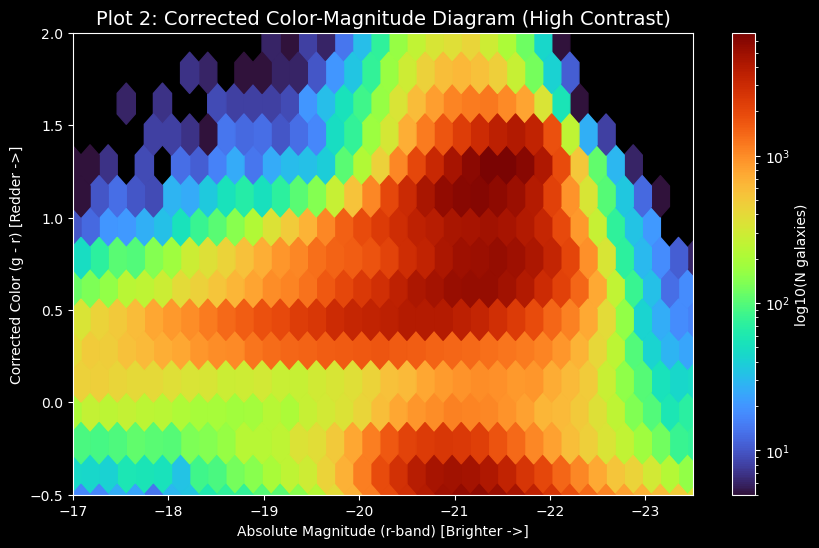

In [14]:
# 1. Apply the empirical correction!
# We subtract the bias (slope * Z) from the original colors to flatten the universe
catalog['corrected_color'] = color_g_r - (slope * catalog['Z'])

# 2. Extract Absolute Magnitude for the X-axis (r-band is the standard baseline)
mag_vals = abs_mag_r 
corrected_color_vals = catalog['corrected_color']

# 3. Create Plot 2: The Color-Magnitude Diagram (CMD)
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# THE FIXES:
# - mincnt=5: Hides any hexagon with less than 5 galaxies. Clears the "fog"!
# - cmap='turbo': A high-contrast rainbow map perfect for showing density peaks.
# - gridsize=100: Slightly larger hexes to smooth out the clusters.
plt.hexbin(mag_vals, corrected_color_vals, gridsize=100, cmap='turbo', bins='log', mincnt=5)
cb = plt.colorbar()
cb.set_label('log10(N galaxies)')

# Invert X-axis
plt.gca().invert_xaxis()

# Zoom in slightly tighter on the Y-axis to frame the split perfectly
plt.xlim(-17, -23.5)
plt.ylim(-0.5, 2.0)

plt.title("Plot 2: Corrected Color-Magnitude Diagram (High Contrast)", fontsize=14)
plt.xlabel("Absolute Magnitude (r-band) [Brighter ->]")
plt.ylabel("Corrected Color (g - r) [Redder ->]")

plt.show()

# Reset the style
plt.style.use('default')

In [ ]:
# Convert absolute magnitudes back to intrinsic linear luminosities
#lum_r = 10 ** (-0.4 * abs_mag_r)
#lum_g = 10 ** (-0.4 * abs_mag_g)

# Normalize the numbers so the Lupton algorithm doesn't freak out over giant scientific values
#norm = np.median(lum_r)
#lum_r = lum_r / norm
#lum_g = lum_g / norm

# Map to RGB
# R = r-band (reddish), B = g-band (blue/greenish)
# We don't have a true deep-blue u-band in the CSV, so we synthesize Green by mixing r and g
#rest_R = lum_r
#rest_G = (lum_r + lum_g) / 2.0
#rest_B = lum_g

# Run the Lupton algorithm
#print("Calculating Rest-Frame RGB...")
# Stretch is slightly higher here because our normalized data centers around 1
#rest_rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=2.0, Q=10)

# Unpack and overwrite our color columns
#r_arr, g_arr, b_arr = rest_rgb_array.T

#catalog['color_r'] = r_arr / 255.0
#catalog['color_g'] = g_arr / 255.0
#catalog['color_b'] = b_arr / 255.0

#print("RGB colors generated!")

In [ ]:
# 1. Convert absolute magnitudes back to intrinsic linear luminosities
# We just use your standalone variables directly!
lum_r = 10 ** (-0.4 * abs_mag_r)
lum_g = 10 ** (-0.4 * abs_mag_g)

# Normalize the numbers so the Lupton algorithm doesn't freak out over giant scientific values
norm = np.percentile(lum_r, 5)
lum_r = lum_r / norm
lum_g = lum_g / norm

# 2. Map to Human Vision (RGB) with a Blue Boost
rest_R = lum_r
rest_G = (lum_r + lum_g) / 2.0
# Multiply the blue channel by 1.5 to artificially boost the young star-forming regions
rest_B = lum_g * 1.5 

# 3. Run the Lupton algorithm
print("Calculating Boosted RGB...")
# Lower stretch = brighter overall. Lower Q = deeply saturated colors!
rest_rgb_array = make_lupton_rgb(rest_R, rest_G, rest_B, stretch=0.2, Q=2)

# 4. Unpack and overwrite our color columns
r_arr, g_arr, b_arr = rest_rgb_array.T

catalog['color_r'] = r_arr / 255.0
catalog['color_g'] = g_arr / 255.0
catalog['color_b'] = b_arr / 255.0

print("Boosted colors generated!")

Calculating Hollywood RGB...
Hollywood colors generated!


In [13]:
# Create the final table, now including the Lupton RGB columns!
table = Table(
    [x, y, z, redshift, zerr, zwarn, object_type, flux_g, flux_r, flux_z, flux_w1, flux_w2, app_mag_G, app_mag_R, app_mag_Z, app_mag_W1, app_mag_W2, abs_mag_g, abs_mag_r, abs_mag_z, abs_mag_w1, abs_mag_w2, catalog['color_r'], catalog['color_g'], catalog['color_b']], 
    names=['x', 'y', 'z', 'redshift', 'zerr', 'zwarn', 'object_type', 'flux_g', 'flux_r', 'flux_z', 'flux_w1', 'flux_w2', 'app_mag_G', 'app_mag_R', 'app_mag_Z', 'app_mag_W1', 'app_mag_W2', 'abs_mag_g', 'abs_mag_r', 'abs_mag_z', 'abs_mag_w1', 'abs_mag_w2', 'color_r', 'color_g', 'color_b']
)



# ... (Your existing table = Table(...) code is up here) ...

# 1. The Dimension Fix: Hunt down and flatten any sneaky 2D columns
for col in table.colnames:
    if len(table[col].shape) > 1:
        # np.squeeze removes empty extra dimensions (turns (1000, 1) into (1000,))
        table[col] = np.squeeze(table[col])

# 2. Save it directly to the assets folder
table.write('openspace_assets/desi_catalog_boosted.csv', format='csv', overwrite=True)
print("Final CSV saved with RGB colors!")

Final CSV saved with RGB colors!
